# 📌 영국시장의 중고차 가격 데이트 분석

## Step 1. 데이터 불러오기

In [7]:
import pandas as pd
import numpy as np

pd.read_csv("cars.csv")


,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN
3683,AUDI A4,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN
3684,BMW 3 SERIES,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN
3685,HONDA ACCORD,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full


## Step 2. cars + brand 합치기

In [10]:
cars = pd.read_csv("cars.csv")
cars['brand'] = cars['title'].str.split().str[0]
cars['brand'].head()


0       SKODA
1    VAUXHALL
2     HYUNDAI
3        MINI
4    VAUXHALL
Name: brand, dtype: object

## Step 3. 카테고리 → 숫자 변환

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['Engine', 'Emission Class']

for col in cat_cols:
    cars[col] = le.fit_transform(cars[col].astype(str))

cars[['Engine', 'Emission Class']].head()

,Engine,Emission Class
0,18,5
1,15,3
2,18,4
3,18,3
4,17,4


In [45]:
cars.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   object 
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   object 
 12  Service history    540 non-null    object 
 13  brand              3687 non-null   object 
dtypes: float64(3), int64(3), object(8)
memory usage: 403.4+ KB


## Step 4.결측치 처리

In [20]:
# Service history → 'Unknown'

cars['Service history'] = cars['Service history'].fillna('Unknown')

cars['Service history'].isnull().sum()

np.int64(0)

## Step 5. 숫자 데이터만 추출 후 스케일링

In [26]:
import pandas as pd

cars = pd.read_csv("cars.csv")
brand = pd.read_csv("brand.csv")

cars["brand"] = cars["title"].str.split().str[0].str.lower()
brand["title"] = brand["title"].str.lower()

df = cars.merge(
    brand,
    left_on="brand",
    right_on="title",
    how="left"
)

df["Service history"] = df["Service history"].fillna("Unknown")


In [28]:
# 카테고리 → 숫자 변환
df_encoded = pd.get_dummies(
    df,
    columns=["Engine", "Emission Class"],
    drop_first=True
)
df_encoded.head()

,title_x,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Gearbox,Doors,Seats,...,Engine_4.4L,Engine_4.8L,Engine_5.0L,Engine_5.5L,Engine_6.3L,Emission Class_Euro 2,Emission Class_Euro 3,Emission Class_Euro 4,Emission Class_Euro 5,Emission Class_Euro 6
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,Manual,5.0,5.0,...,False,False,False,False,False,False,False,False,False,True
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,Manual,3.0,5.0,...,False,False,False,False,False,False,False,True,False,False
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,Manual,5.0,5.0,...,False,False,False,False,False,False,False,False,True,False
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,Manual,3.0,4.0,...,False,False,False,False,False,False,False,True,False,False
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,Manual,5.0,5.0,...,False,False,False,False,False,False,False,False,True,False


## Step 6. PCA

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

target = "Price"

numeric_cols = df_encoded.select_dtypes(include=np.number).columns
feature_cols = [c for c in numeric_cols if c != target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded[feature_cols])

In [33]:
# (중앙값)
df_encoded[feature_cols] = df_encoded[feature_cols].fillna(
    df_encoded[feature_cols].median()
)


원본 변수 개수: 5
선택된 주성분 개수: 3
누적 설명 분산 비율: 0.7966803926565372


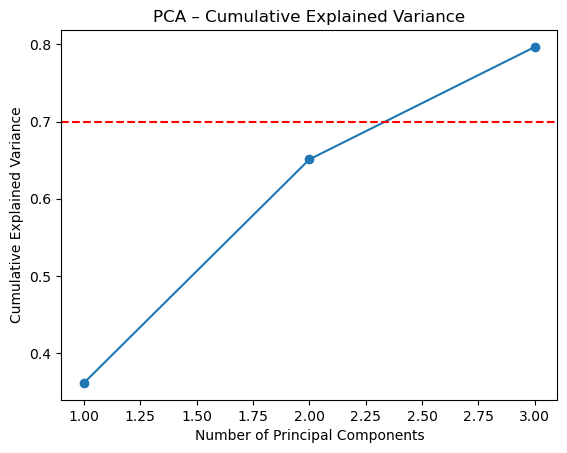

In [39]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA(n_components=0.7, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("원본 변수 개수:", X_scaled.shape[1])
print("선택된 주성분 개수:", X_pca.shape[1])
print("누적 설명 분산 비율:", pca.explained_variance_ratio_.sum())

# 누적 설명 분산 시각화
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.7, color='red', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA – Cumulative Explained Variance")
plt.show()


## Step 7. 국가별 브랜드 개수

In [40]:
cars = pd.read_csv("cars.csv")
cars['brand'] = cars['title'].str.split().str[0]
cars['brand'].head()


0       SKODA
1    VAUXHALL
2     HYUNDAI
3        MINI
4    VAUXHALL
Name: brand, dtype: object

In [41]:
# Step 2-2. 가격과 주요 변수 간 상관관계
corr = df_encoded.corr(numeric_only=True)

corr["Price"].sort_values(ascending=False)


Price                    1.000000
Emission Class_Euro 6    0.734429
Registration_Year        0.722971
Engine_1.5L              0.222744
Engine_1.0L              0.148611
Doors                    0.113168
Engine_2.0L              0.106652
Engine_3.0L              0.031752
Engine_4.2L              0.030897
Engine_2.1L              0.022099
Engine_6.3L              0.018613
Engine_0.9L              0.018543
Engine_5.5L              0.015488
Engine_2.6L              0.006859
Engine_1.3L              0.005946
Engine_2.3L              0.004220
Engine_4.4L             -0.002692
Engine_3.1L             -0.005652
Engine_4.8L             -0.006571
Engine_4.3L             -0.008917
Engine_5.0L             -0.009283
Engine_3.3L             -0.010432
Engine_3.7L             -0.011604
Engine_2.7L             -0.015126
Engine_3.5L             -0.016738
Engine_1.7L             -0.019198
Engine_2.8L             -0.019262
Engine_3.2L             -0.024821
Seats                   -0.027501
Engine_2.5L   

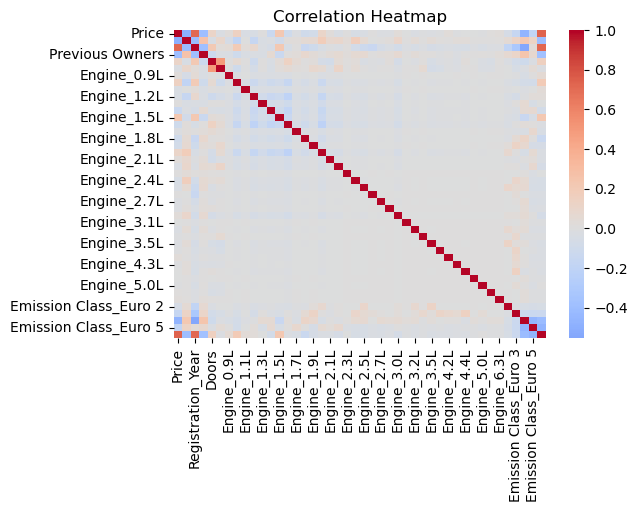

In [42]:
# 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()


## Step 8. 상관관계 확인

In [47]:
# 숫자형 변수들 간 상관관계 계산
corr = df_encoded.corr(numeric_only=True)

# Price와의 상관관계만 확인
corr["Price"].sort_values(ascending=False)


Price                    1.000000
Emission Class_Euro 6    0.734429
Registration_Year        0.722971
Engine_1.5L              0.222744
Engine_1.0L              0.148611
Doors                    0.113168
Engine_2.0L              0.106652
Engine_3.0L              0.031752
Engine_4.2L              0.030897
Engine_2.1L              0.022099
Engine_6.3L              0.018613
Engine_0.9L              0.018543
Engine_5.5L              0.015488
Engine_2.6L              0.006859
Engine_1.3L              0.005946
Engine_2.3L              0.004220
Engine_4.4L             -0.002692
Engine_3.1L             -0.005652
Engine_4.8L             -0.006571
Engine_4.3L             -0.008917
Engine_5.0L             -0.009283
Engine_3.3L             -0.010432
Engine_3.7L             -0.011604
Engine_2.7L             -0.015126
Engine_3.5L             -0.016738
Engine_1.7L             -0.019198
Engine_2.8L             -0.019262
Engine_3.2L             -0.024821
Seats                   -0.027501
Engine_2.5L   

## Step 9. PCA 전·후 비교

In [48]:
print("PCA 적용 전 변수 개수:", X_scaled.shape[1])
print("PCA 적용 후 주성분 개수:", X_pca.shape[1])
print("누적 설명 분산 비율:", pca.explained_variance_ratio_.sum())


PCA 적용 전 변수 개수: 5
PCA 적용 후 주성분 개수: 3
누적 설명 분산 비율: 0.7966803926565372


## Step 10. 주요 변수 분포 확인

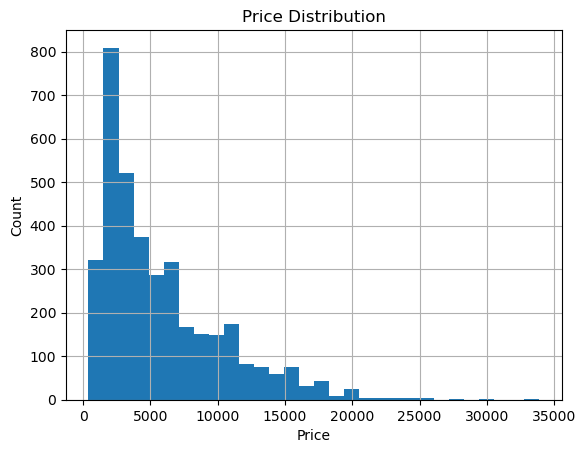

In [49]:
df["Price"].hist(bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


## Step 11. 브랜드별 평균 가격

In [51]:
brand_price = (
    df.groupby("brand")["Price"]
      .mean()
      .sort_values(ascending=False)
)

brand_price.head(10)

brand
lagonda      14995.000000
ds           14293.833333
maserati     13300.000000
marcos       11495.000000
abarth       11216.333333
land         10741.428571
mg            9173.600000
jaguar        8680.766667
ssangyong     8636.000000
infiniti      8625.714286
Name: Price, dtype: float64

브랜드별 평균 가격을 비교한 결과, 일부 프리미엄 브랜드의 평균 가격이
상대적으로 높게 나타났다.